Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.1%


C:\Users\HP\AppData\Local\Temp\ipykernel_10788\3088935970.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attrition', palette='Set2')


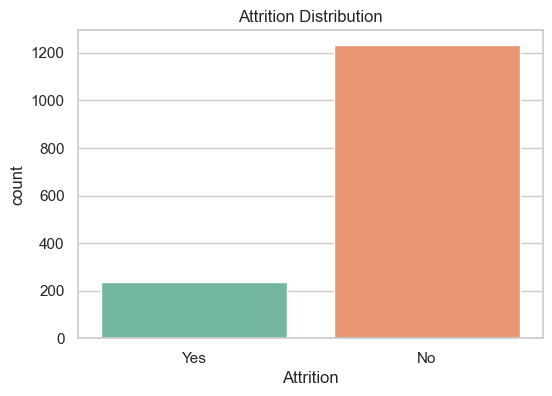

In [ ]:
# How balanced is our target?
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_counts['Yes'] / len(df) * 100:.1f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Attrition Distribution')
plt.show()

In [1]:
# How balanced is our target?
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f"\nAttrition Rate: {attrition_counts['Yes'] / len(df) * 100:.1f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Attrition Distribution')
plt.show()

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# These columns have zero variance - they're the same value for every employee
# A column that never changes cannot help predict anything
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18']
df = df.drop(columns=cols_to_drop)

print("Shape after dropping useless columns:", df.shape)
# Expected: (1470, 31)


Shape after dropping useless columns: (1470, 31)


In [3]:
# Convert Attrition from Yes/No to 1/0
# Why? Models only understand numbers, not words
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Target distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].mean()*100:.1f}%")

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [4]:
# These columns only have 2 values so we map them directly to 0 and 1
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

print("Binary encoding done!")
print(df[['OverTime', 'Gender']].head())

Binary encoding done!
   OverTime  Gender
0         1       0
1         0       1
2         1       1
3         1       0
4         0       1


In [5]:
# These columns have 3+ categories
# We convert each category into its own 0/1 column
# Why? A model can't understand that "Sales" > "HR" > "R&D" — they're not ranked
# So we give each its own column instead

df = pd.get_dummies(df, columns=['BusinessTravel', 'Department',
                                  'EducationField', 'JobRole',
                                  'MaritalStatus'], drop_first=False)

print("Shape after one-hot encoding:", df.shape)

Shape after one-hot encoding: (1470, 50)


In [6]:
# These new columns capture relationships the raw data doesn't express directly

# 1. Income per year of experience — captures pay fairness
df['IncomePerYear'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)

# 2. Loyalty score — how much of career spent at this company
df['LoyaltyScore'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

# 3. Average satisfaction across all satisfaction metrics
df['AvgSatisfaction'] = df[['EnvironmentSatisfaction',
                              'JobSatisfaction',
                              'RelationshipSatisfaction',
                              'WorkLifeBalance']].mean(axis=1)

print("New features added!")
print(df[['IncomePerYear', 'LoyaltyScore', 'AvgSatisfaction']].describe())

New features added!
       IncomePerYear  LoyaltyScore  AvgSatisfaction
count    1470.000000   1470.000000      1470.000000
mean      587.575385      0.581830         2.730952
std       284.650784      0.284476         0.505815
min        95.285714      0.000000         1.000000
25%       374.232143      0.368421         2.500000
50%       549.220648      0.636364         2.750000
75%       738.303846      0.833333         3.000000
max      1904.000000      0.975610         4.000000


In [7]:
# Save processed data so we don't redo this in the modelling notebook
df.to_csv('../data/hr_processed.csv', index=False)

print("✅ Processed dataset saved!")
print("Final shape:", df.shape)
print("\nAll columns:", df.columns.tolist())

✅ Processed dataset saved!
Final shape: (1470, 53)

All columns: ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technicia